<a href="https://colab.research.google.com/github/nawaltahir/codealpha_tasks/blob/main/Automated_Essay_Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()  # Upload kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nawaltahir","key":"aec9d43a18739d8654564cc9695ab994"}'}

In [2]:
import os
import zipfile

# Create the Kaggle directory and move the token there
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/kaggle.json

# Set permissions
!chmod 600 /root/.kaggle/kaggle.json


In [3]:
!pip install -q kaggle

# Download the dataset
!kaggle datasets download -d lburleigh/asap-2-0


Dataset URL: https://www.kaggle.com/datasets/lburleigh/asap-2-0
License(s): Attribution 4.0 International (CC BY 4.0)


In [4]:
# Unzip
with zipfile.ZipFile("asap-2-0.zip", 'r') as zip_ref:
    zip_ref.extractall("asap_data")

# List files
os.listdir("asap_data")


['ASAP2_train_sourcetexts.csv']

In [5]:
import pandas as pd

# Update the path to include the "asap_data" directory
df = pd.read_csv("asap_data/ASAP2_train_sourcetexts.csv")
df.head()

,essay_id,score,full_text,assignment,prompt_name,economically_disadvantaged,student_disability_status,ell_status,race_ethnicity,gender,source_text_1,source_text_2,source_text_3,source_text_4
0,AAAVUP14319000159574,4,The author suggests that studying Venus is wor...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,Black/African American,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
1,AAAVUP14319000159542,2,NASA is fighting to be alble to to go to Venus...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Not economically disadvantaged,Not identified as having disability,No,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
2,AAAVUP14319000159461,3,"""The Evening Star"", is one of the brightest po...","In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,White,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
3,AAAVUP14319000159420,2,The author supports this idea because from rea...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
4,AAAVUP14319000159419,2,How the author supports this idea is that he s...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN


In [6]:
!pip install -q sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 37.5 MB/s eta 0:00:00


In [7]:
import pandas as pd
import re

# Load your dataset
df = pd.read_csv("asap_data/ASAP2_train_sourcetexts.csv")

# Clean essay text
def clean_text(text):
    text = re.sub(r'\W+', ' ', str(text)).lower()
    return text

df['clean_text'] = df['full_text'].apply(clean_text)

# Drop rows without scores if needed
df = df[df['score'].notnull()]

In [8]:
# 📌 4. Generate SBERT Embeddings using paraphrase-mpnet-base-v2
from sentence_transformers import SentenceTransformer
model_name = 'paraphrase-mpnet-base-v2'
sbert = SentenceTransformer(model_name)

# Confirm GPU use
import torch
print(f"Using device: {sbert.device}")

X_text = sbert.encode(
    df['clean_text'].tolist(),
    batch_size=16,               # Lower for larger models
    #device='cuda',               # Will run much faster with GPU
    show_progress_bar=True
)
import numpy as np
# Save embeddings (optional)
np.save("essay_embeddings_mpnet.npy", X_text)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.52k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Using device: cuda:0


Batches:   0%|          | 0/1546 [00:00<?, ?it/s]

In [9]:
# 📌 5. Prepare Metadata
from sklearn.preprocessing import OneHotEncoder
metadata_cols = [
    'gender', 'race_ethnicity', 'assignment', 'prompt_name',
    'economically_disadvantaged', 'student_disability_status', 'ell_status'
]
X_meta = df[metadata_cols].fillna("Unknown")

# One-hot encode metadata
encoder = OneHotEncoder(handle_unknown='ignore')
X_meta_encoded = encoder.fit_transform(X_meta)



In [10]:
# 📌 6. Combine Text + Metadata
X_combined = np.hstack([X_text, X_meta_encoded.toarray()])
y = df['score']

In [11]:
# 📌 7. Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_combined, y, test_size=0.2, random_state=42
)


In [12]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
# 📌 8. Train Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_preds = ridge.predict(X_val)
ridge_mse = mean_squared_error(y_val, ridge_preds)
print(f"Ridge + Metadata MSE: {ridge_mse:.4f}")

# 📌 9. Train LightGBM
lgb = LGBMRegressor(n_estimators=100)
lgb.fit(X_train, y_train)
lgb_preds = lgb.predict(X_val)
lgb_mse = mean_squared_error(y_val, lgb_preds)
print(f"LightGBM + Metadata MSE: {lgb_mse:.4f}")

# 📌 10. Optional Blending
blended_preds = 0.5 * ridge_preds + 0.5 * lgb_preds
blend_mse = mean_squared_error(y_val, blended_preds)
print(f"Blended Ridge + LightGBM MSE: {blend_mse:.4f}")

Ridge + Metadata MSE: 0.4219


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.391786 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195902
[LightGBM] [Info] Number of data points in the train set: 19782, number of used features: 799
[LightGBM] [Info] Start training from score 2.941108
LightGBM + Metadata MSE: 0.5443
Blended Ridge + LightGBM MSE: 0.4401


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [13]:
import joblib
joblib.dump(ridge, "ridge_model.pkl")
lgb.booster_.save_model("lgb_model.txt")
joblib.dump(encoder, "scaler_encoder.pkl")


['scaler_encoder.pkl']

In [14]:
!pip install -q huggingface_hub
from huggingface_hub import notebook_login

notebook_login()


In [15]:
import joblib
import os

# Create model directory
model_dir = "essay_scoring_model"
os.makedirs(model_dir, exist_ok=True)

# Save column order to a JSON file
import json
with open(os.path.join(model_dir, "metadata_columns.json"), "w") as f:
    json.dump(metadata_cols, f)

# Optionally, also save the one-hot feature names for clarity
feature_names = encoder.get_feature_names_out(metadata_cols).tolist()
with open(os.path.join(model_dir, "encoded_feature_names.json"), "w") as f:
    json.dump(feature_names, f)

# Save your Ridge and LightGBM models
joblib.dump(ridge, os.path.join(model_dir, "ridge_model.pkl"))
joblib.dump(lgb, os.path.join(model_dir, "lightgbm_model.pkl"))

# Optionally: save any metadata (scalers, encoders, etc.)
joblib.dump(encoder, os.path.join(model_dir, "scaler_encoder.pkl"))



['essay_scoring_model/scaler_encoder.pkl']

In [16]:
from huggingface_hub import create_repo, upload_folder

repo_id = "Nawal20/Essay"  # Change to your actual username/repo

# Create the repo (set private=True if needed)
#create_repo(repo_id, private=False)

# Upload the entire model folder
upload_folder(
    folder_path=model_dir,
    path_in_repo=".",
    repo_id=repo_id,
    repo_type="model"
)


CommitInfo(commit_url='https://huggingface.co/Nawal20/Essay/commit/cdec045d5b1488a54e4e11284dab43df56177f6c', commit_message='Upload folder using huggingface_hub', commit_description='', oid='cdec045d5b1488a54e4e11284dab43df56177f6c', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Nawal20/Essay', endpoint='https://huggingface.co', repo_type='model', repo_id='Nawal20/Essay'), pr_revision=None, pr_num=None)

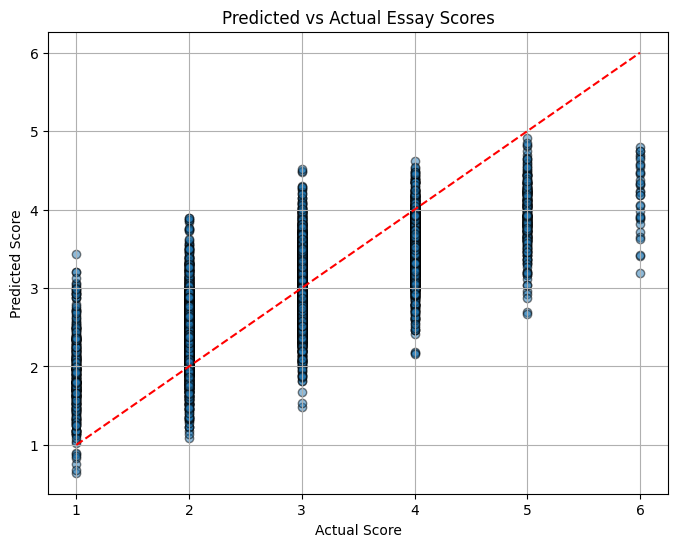

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_val, blended_preds, alpha=0.5, edgecolor='k')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')  # Diagonal
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Predicted vs Actual Essay Scores")
plt.grid(True)
plt.show()


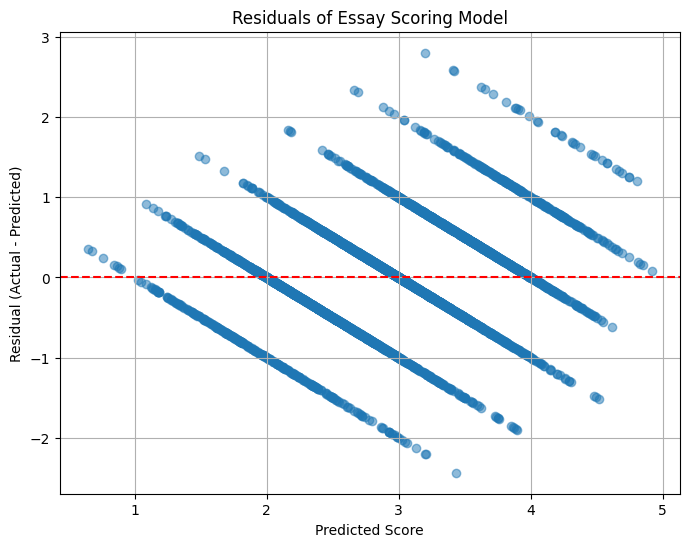

In [ ]:
residuals = y_val - blended_preds

plt.figure(figsize=(8, 6))
plt.scatter(blended_preds, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Score")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals of Essay Scoring Model")
plt.grid(True)
plt.show()


In [ ]:
!pip install -U sympy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 15.7 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires sympy==1.13.1; python_version >= "3.9", but you have sympy 1.13.3 which is incompatible.


In [ ]:
!nvidia-smi

Fri Apr 11 13:20:58 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----